# Machine Learning-Based Driver Behavior Analysis and Accident Risk Prediction System

**Student Name:** Satish Adhikari  
**Programme:** MSc Data Science and Computational Intelligence  
**Project Type:** Machine Learning Classification and Clustering Prototype  
**Tools:** Python, Jupyter Notebook, Pandas, Scikit-learn, Matplotlib, Seaborn

## 1. Import Required Libraries

In [3]:
# Machine Learning-Based Driver Behavior Analysis and Accident Risk Prediction System

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

## 2. Load Dataset

In [5]:
# Load dataset

df = pd.read_csv("../data/RTA Dataset.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully
Shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [6]:
# Show all column names

print(df.columns.tolist())

# Basic information
df.info()


['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  123

## 3. Data Cleaning and Preprocessing

In [8]:
# Check missing values before cleaning

missing_before = df.isnull().sum()
missing_before[missing_before > 0].sort_values(ascending=False)

Defect_of_vehicle          4427
Service_year_of_vehicle    3928
Work_of_casuality          3198
Fitness_of_casuality       2635
Type_of_vehicle             950
Types_of_Junction           887
Driving_experience          829
Educational_level           741
Vehicle_driver_relation     579
Owner_of_vehicle            482
Lanes_or_Medians            385
Vehicle_movement            308
Area_accident_occured       239
Road_surface_type           172
Type_of_collision           155
Road_allignment             142
dtype: int64

In [9]:
# Drop heavily missing columns

df = df.drop(columns=['Defect_of_vehicle', 'Service_year_of_vehicle'])

print("Updated Shape:", df.shape)

Updated Shape: (12316, 30)


In [10]:
# Fill remaining missing values with mode

for col in df.columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [11]:
# Target class distribution

df['Accident_severity'].value_counts()

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

In [12]:
# Encode categorical columns

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,420,1,0,1,0,0,0,0,3,9,...,2,3,2,5,3,0,2,5,9,2
1,420,1,1,1,4,0,3,11,3,6,...,2,3,2,5,3,0,2,5,16,2
2,420,1,0,1,4,0,0,5,3,1,...,2,0,1,1,2,0,2,5,0,1
3,594,3,0,1,4,0,2,11,0,6,...,2,2,0,0,2,0,2,5,1,2
4,594,3,0,1,4,0,1,0,3,4,...,2,3,2,5,3,0,2,5,16,2


In [13]:
# Features and target

X = df_encoded.drop('Accident_severity', axis=1)
y = df_encoded['Accident_severity']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (12316, 29)
y Shape: (12316,)


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    
    plt.figure(figsize=(12,6))
    missing.plot(kind='bar')
    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

else:
    print("No Missing Values Found in Dataset")

No Missing Values Found in Dataset


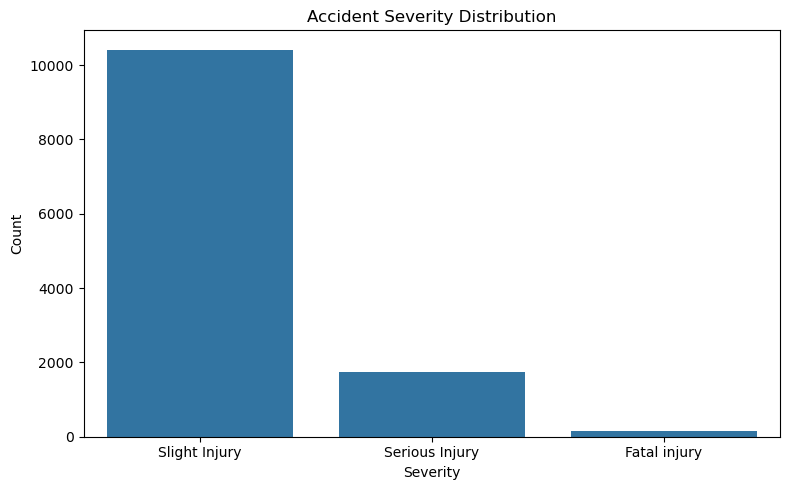

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Accident_severity', data=df)
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/accident_severity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

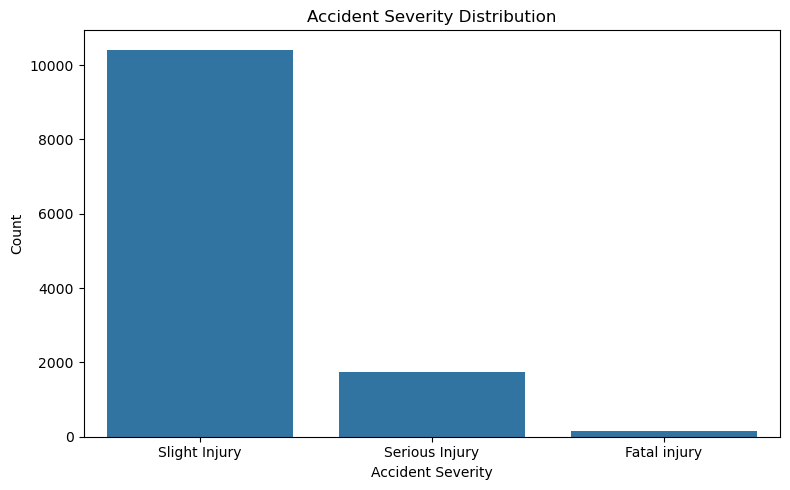

In [16]:
# Save Accident Severity Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='Accident_severity', data=df)

plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("outputs/accident_severity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

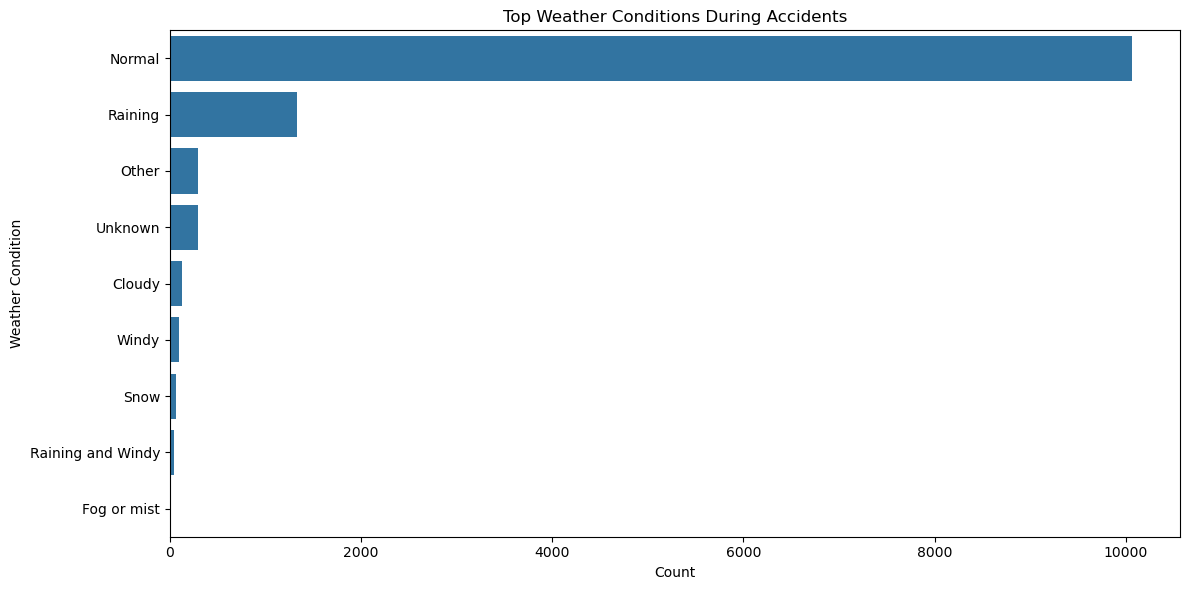

In [17]:
# Weather Conditions Graph

plt.figure(figsize=(12,6))
sns.countplot(
    y='Weather_conditions',
    data=df,
    order=df['Weather_conditions'].value_counts().iloc[:10].index
)

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Count")
plt.ylabel("Weather Condition")

plt.tight_layout()
plt.show()

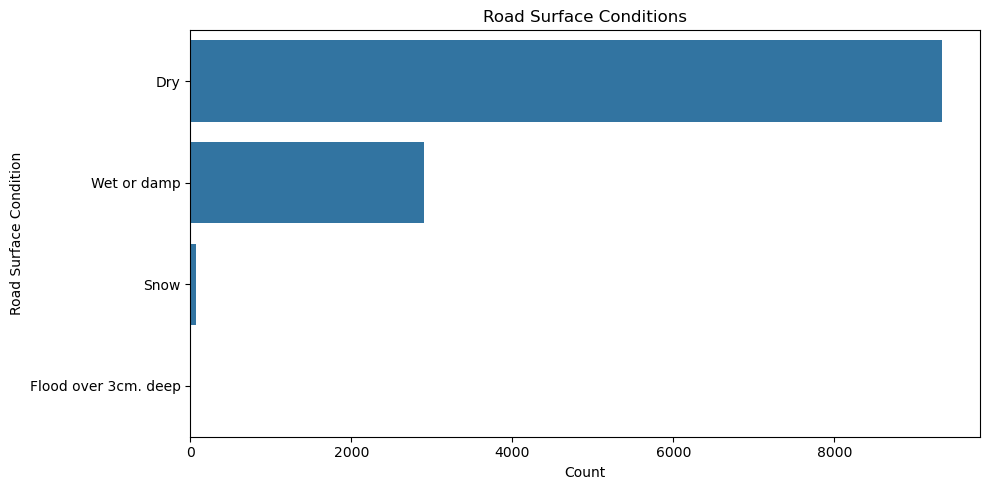

In [18]:
# Road Surface Conditions Graph

plt.figure(figsize=(10,5))
sns.countplot(
    y='Road_surface_conditions',
    data=df,
    order=df['Road_surface_conditions'].value_counts().index
)

plt.title("Road Surface Conditions")
plt.xlabel("Count")
plt.ylabel("Road Surface Condition")

plt.tight_layout()
plt.show()

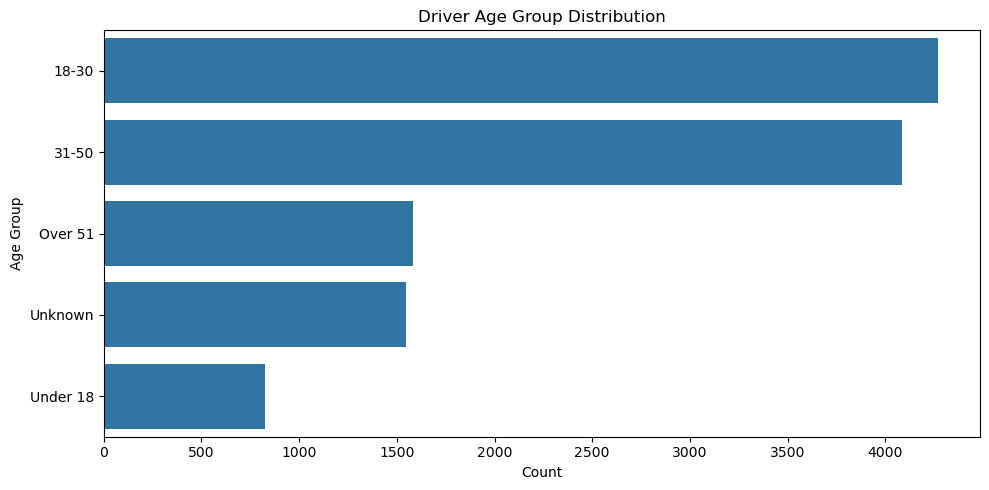

In [19]:
# Driver Age Group Distribution

plt.figure(figsize=(10,5))
sns.countplot(
    y='Age_band_of_driver',
    data=df,
    order=df['Age_band_of_driver'].value_counts().index
)

plt.title("Driver Age Group Distribution")
plt.xlabel("Count")
plt.ylabel("Age Group")

plt.tight_layout()
plt.savefig("outputs/driver_age_group_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

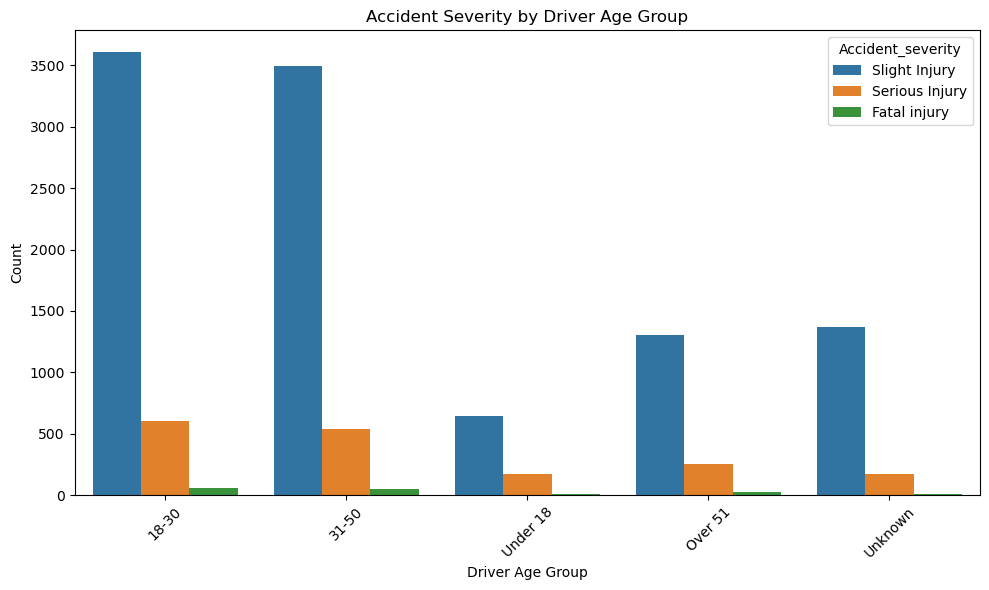

In [20]:
# Accident Severity by Driver Age Group

plt.figure(figsize=(10,6))
sns.countplot(
    x='Age_band_of_driver',
    hue='Accident_severity',
    data=df
)

plt.title("Accident Severity by Driver Age Group")
plt.xlabel("Driver Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("outputs/severity_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

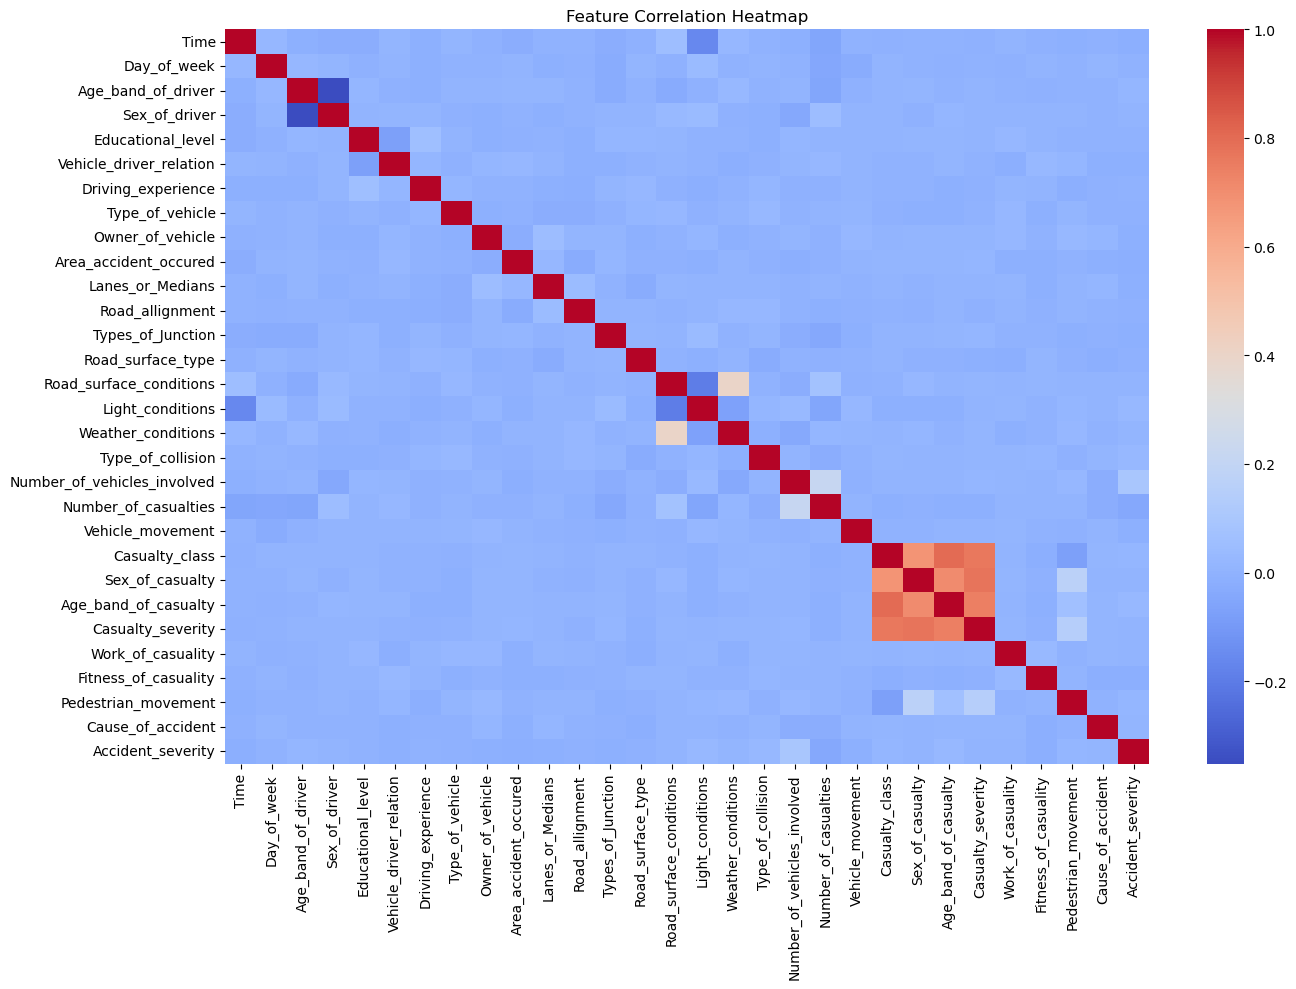

In [21]:
from sklearn.preprocessing import LabelEncoder

temp_df = df.copy()

for col in temp_df.columns:
    if temp_df[col].dtype == 'object':
        temp_df[col] = LabelEncoder().fit_transform(temp_df[col].astype(str))

plt.figure(figsize=(14,10))
sns.heatmap(temp_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

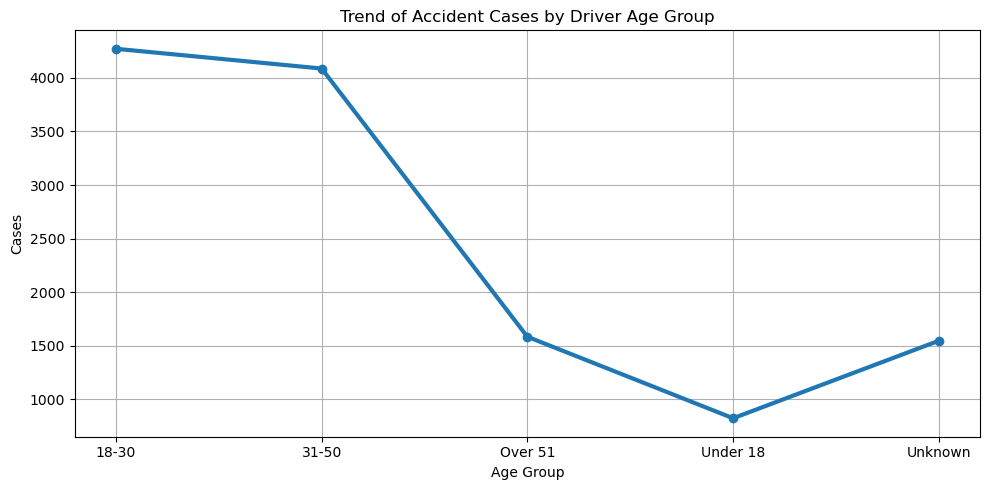

In [22]:
age_counts = df['Age_band_of_driver'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(age_counts.index, age_counts.values, marker='o', linewidth=3)

plt.title("Trend of Accident Cases by Driver Age Group")
plt.xlabel("Age Group")
plt.ylabel("Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Machine Learning Model Training

In [24]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (9852, 29)
Testing Data: (2464, 29)


In [25]:
# Logistic Regression Model

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8453733766233766


In [26]:
# Decision Tree Model

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7435064935064936


In [27]:
# Random Forest Model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8482142857142857


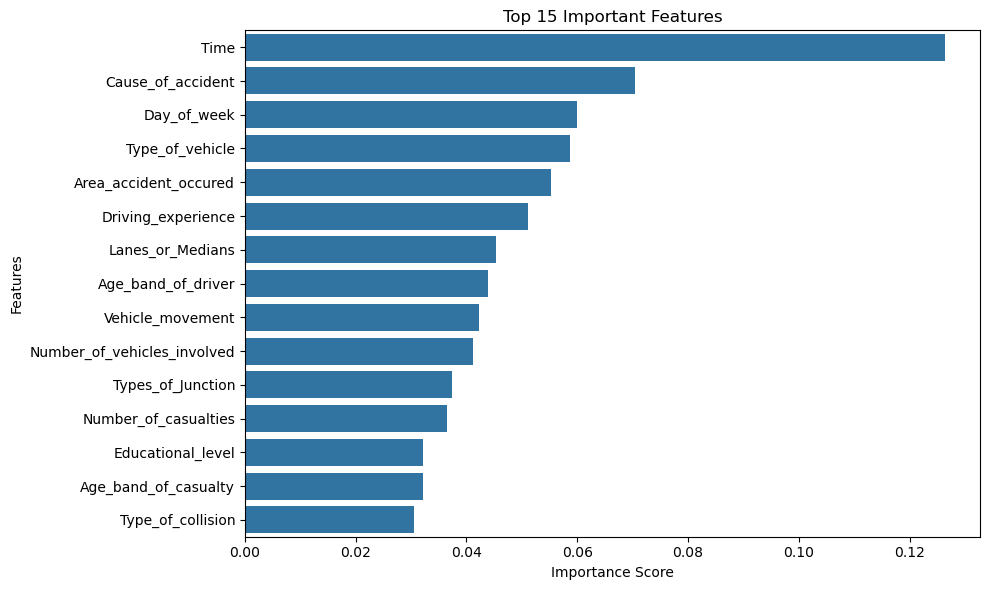

In [28]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 5. Performance Evaluation

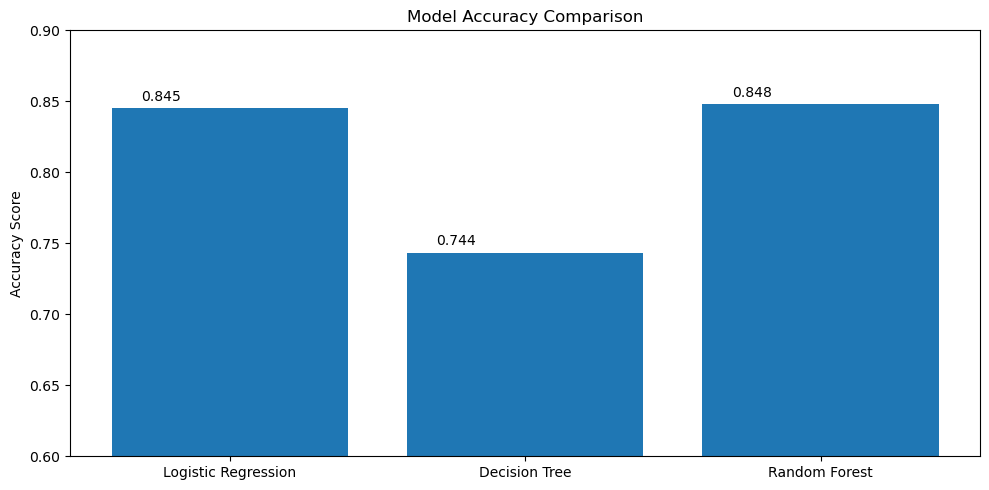

In [30]:
# Model Accuracy Comparison

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(10,5))
bars = plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0.6, 0.9)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + 0.1, y + 0.005, round(y, 3))

plt.tight_layout()
plt.savefig("outputs/model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

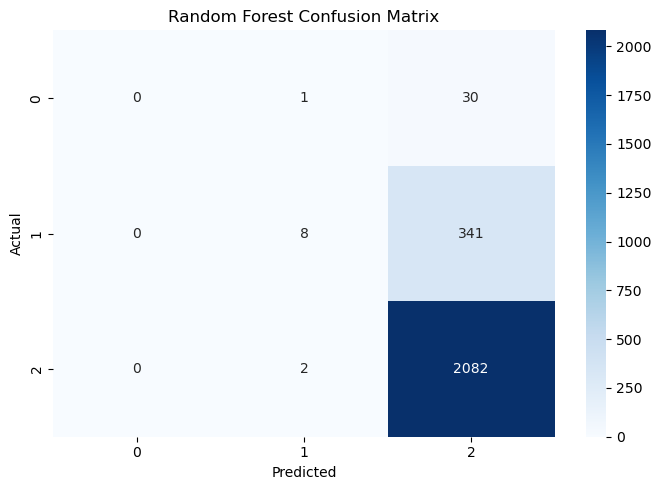

In [31]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# Save best model

joblib.dump(rf, "models/best_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


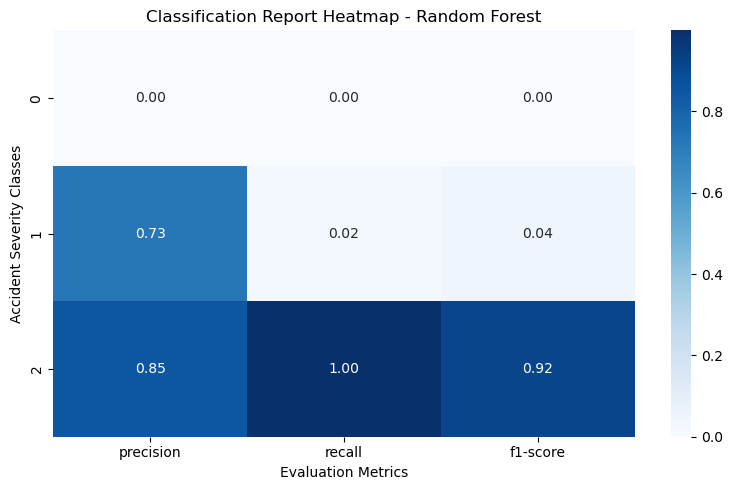

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.73      0.02      0.04       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.53      0.34      0.32      2464
weighted avg       0.82      0.85      0.78      2464



In [33]:
# Classification Report Heatmap

report = classification_report(y_test, rf_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_plot = report_df.iloc[:-3, :3]

plt.figure(figsize=(8,5))
sns.heatmap(report_plot, annot=True, cmap="Blues", fmt=".2f")

plt.title("Classification Report Heatmap - Random Forest")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Accident Severity Classes")

plt.tight_layout()
plt.savefig("outputs/classification_report_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(y_test, rf_pred))

## 6. Unsupervised Learning (K-Means Clustering)

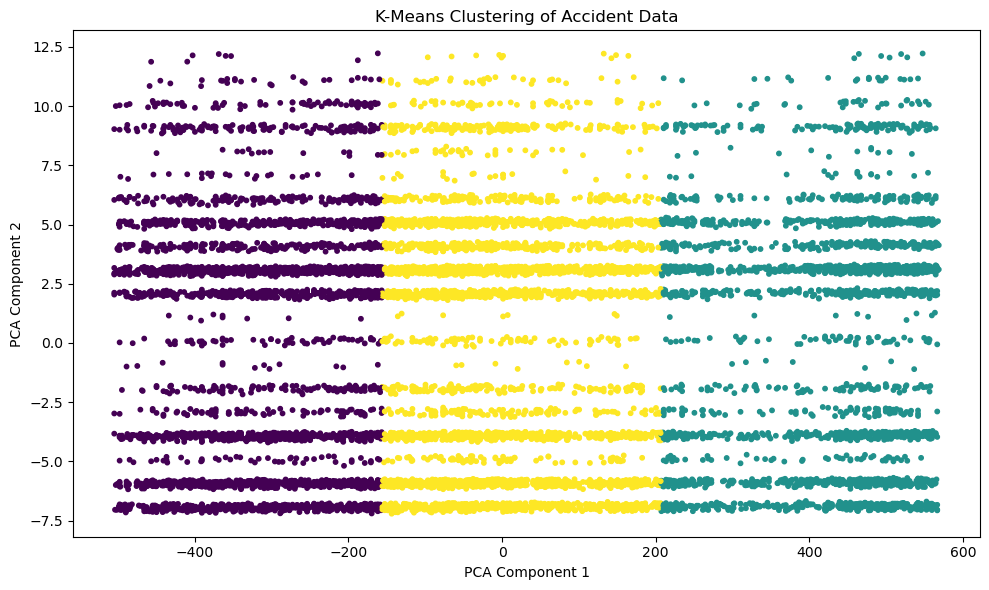

In [35]:
# PCA + K-Means Clustering

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=10)

plt.title("K-Means Clustering of Accident Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.tight_layout()
plt.savefig("outputs/kmeans_clustering.png", dpi=300, bbox_inches="tight")
plt.show()

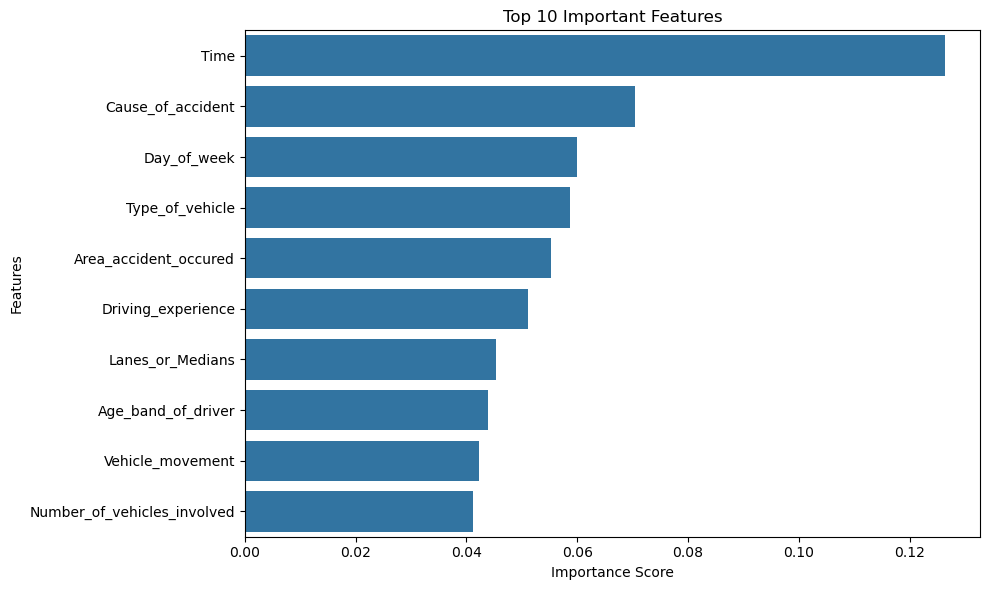

In [36]:
# Feature Importance

importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Final Conclusion

In [38]:
# Final model evaluation

print("Final Random Forest Accuracy:", rf_acc)
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Final Random Forest Accuracy: 0.8482142857142857

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.73      0.02      0.04       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.53      0.34      0.32      2464
weighted avg       0.82      0.85      0.78      2464



## Final Conclusion

Among all tested models, Random Forest achieved the best prediction accuracy for accident severity classification.

This project demonstrates that machine learning can support road safety analysis and accident risk prediction using historical traffic accident data.

Future improvements may include real-time sensor data, GPS integration, and Nepal-specific traffic datasets.